In [140]:
import pandas as pd
df=pd.read_csv(r'C:\Users\Hichem\Downloads\healthcare-dataset-stroke-data.csv')


In [141]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [142]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [143]:
df['bmi'].isna().sum()

np.int64(201)

In [144]:
df['bmi']=df['bmi'].fillna(df['bmi'].median())

In [145]:
df['bmi'].isna().sum()

np.int64(0)

In [146]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [170]:
avg_age=df.loc[df['stroke']==1,'age'].mean()
print(' Average age of the patients who have a stroke: ',avg_age.astype((int)))



 Average age of the patients who have a stroke:  67


In [172]:
SICK_and_STRIKE =df.loc[(df['stroke']==1) & (df['hypertension']==1) & (df['heart_disease']==1),'id'].count()
print(' Number of persons with heart disease and hyperyension and have a stroke:',SICK_and_STRIKE)

 Number of persons with heart disease and hyperyension and have a stroke: 13


In [149]:
import numpy as np

In [173]:
print ('   Number of person with stroke by gender  ')
gender_stroke=df.loc[df['stroke']==1,'gender'].value_counts()
print(gender_stroke)

   Number of person with stroke by gender  
gender
Female    141
Male      108
Name: count, dtype: int64


In [174]:
print (   'Smoking status & stroke')
smoke=df.loc[df['stroke']==1 , 'smoking_status'].value_counts()
print (smoke)

Smoking status & stroke
smoking_status
never smoked       90
formerly smoked    70
Unknown            47
smokes             42
Name: count, dtype: int64


In [177]:
print ('   Relation between stroke bmi & gluscose level :')
df.groupby('stroke')[['avg_glucose_level', 'bmi']].mean().round(2)

   Relation between stroke bmi & gluscose level :


,avg_glucose_level,bmi
stroke,,
0,104.80,28.80
1,132.54,30.09


In [154]:
import matplotlib.pyplot as plt
import seaborn as sns

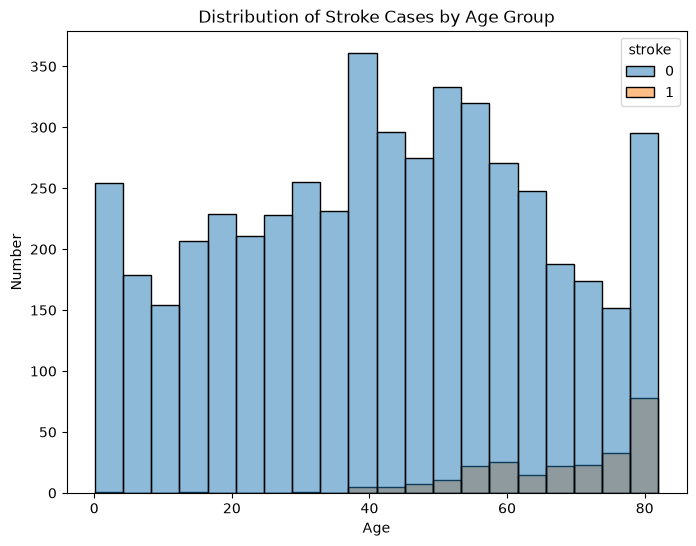

In [178]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='age', hue='stroke')
plt.xlabel('Age')
plt.ylabel('Number')
plt.title('Distribution of Stroke Cases by Age Group')
plt.show()

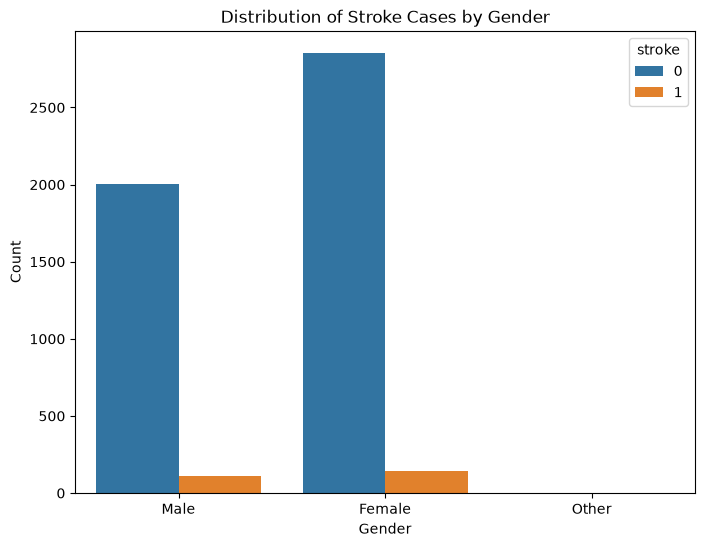

In [180]:
plt.figure(figsize=(8,6))
sns.countplot(data=df,x='gender',hue='stroke')
plt.title('Distribution of Stroke Cases by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

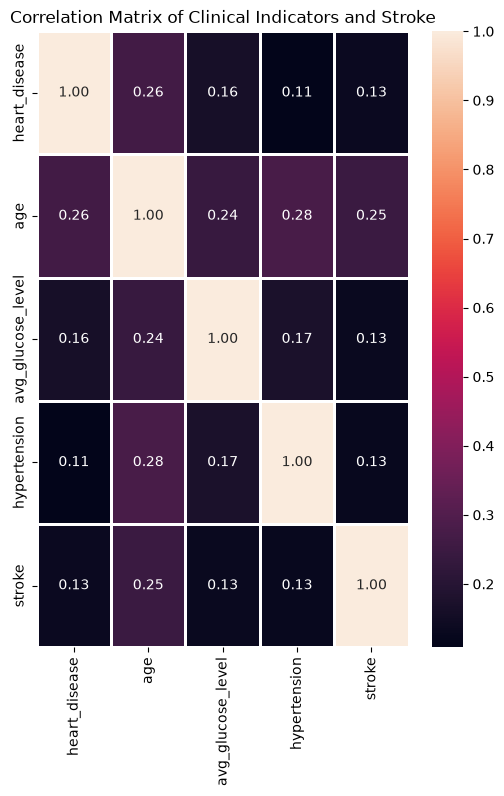

In [181]:
plt.figure(figsize=(6,8))
corr = df[['heart_disease', 'age','avg_glucose_level','hypertension','stroke']].corr()
sns.heatmap(corr, annot=True,fmt='.2f',linewidths=2)
plt.title('Correlation Matrix of Clinical Indicators and Stroke')
plt.show()

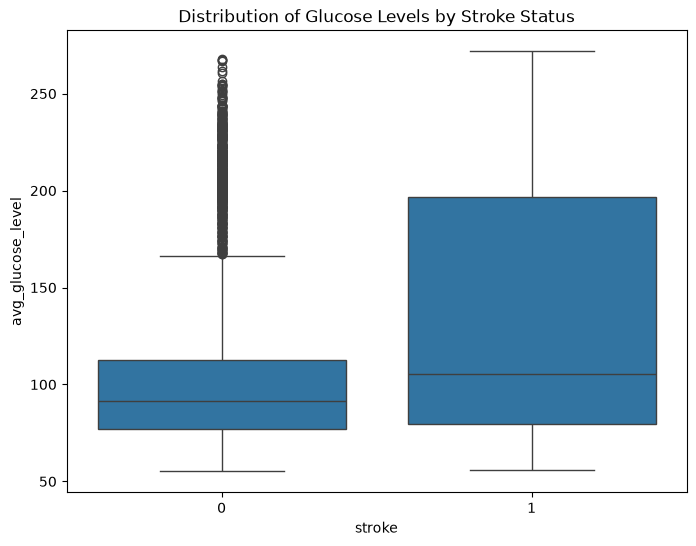

In [182]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='stroke', y='avg_glucose_level')
plt.title('Distribution of Glucose Levels by Stroke Status')
plt.show()

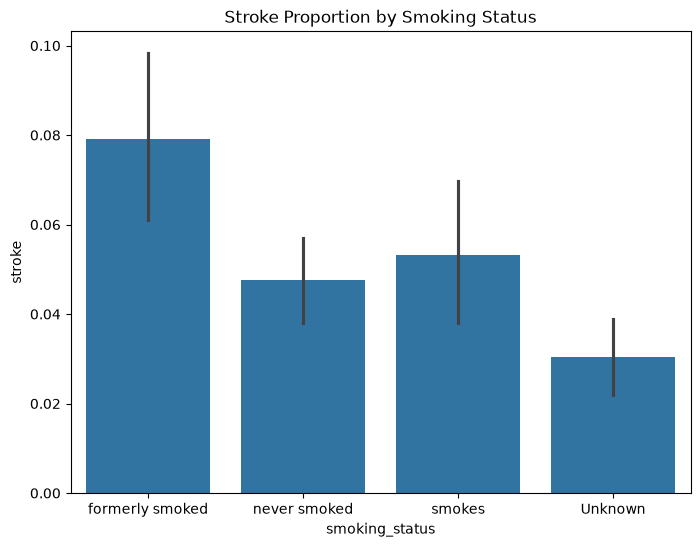

In [183]:
plt.figure(figsize=(8,6))
sns.barplot(data=df, x='smoking_status', y='stroke')
plt.title('Stroke Proportion by Smoking Status')
plt.show()

In [160]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender_encoding']=le.fit_transform(df['gender'])

In [161]:
df[['gender','gender_encoding']].head(2)

,gender,gender_encoding
0,Male,1
1,Female,0


In [162]:
smoke_encode=pd.get_dummies(df['smoking_status'])
df=pd.concat([df,smoke_encode],axis=1)

In [163]:
df['marriage_encode']=le.fit_transform(df['ever_married'])
df[['ever_married','marriage_encode']].head(13)

,ever_married,marriage_encode
0,Yes,1
1,Yes,1
2,Yes,1
3,Yes,1
4,Yes,1
5,Yes,1
6,Yes,1
7,No,0
8,Yes,1
9,Yes,1


In [164]:
work_encode=pd.get_dummies(df['work_type'])
df = pd.concat([df, work_encode], axis=1)

In [165]:
df['resdiance_type_encode']=le.fit_transform(df['Residence_type'])
df[['resdiance_type_encode','Residence_type']].head()

,resdiance_type_encode,Residence_type
0,1,Urban
1,0,Rural
2,0,Rural
3,1,Urban
4,0,Rural


In [71]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke', 'gender_encoding', 'smoking_encoded',
       'marriage_encode', 'resdiance_type_encode', 'Unknown',
       'formerly smoked', 'never smoked', 'smokes', 'Govt_job', 'Never_worked',
       'Private', 'Self-employed', 'children'],
      dtype='str')

In [166]:
y=df['stroke']
x=df.drop(columns=['id', 'stroke', 'gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'])

In [167]:
from sklearn.model_selection import train_test_split
x_train ,x_test ,y_train ,y_test =train_test_split(x ,y, test_size=0.2,random_state=42)
print(x_train.shape, x_test.shape)

(4088, 17) (1022, 17)


In [168]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced')
model.fit(X=x_train,y=y_train)
y_pred=model.predict(x_test)
from sklearn.metrics import confusion_matrix , accuracy_score , classification_report
print(confusion_matrix(y_test , y_pred))
print(accuracy_score(y_test , y_pred))
print(classification_report(y_test , y_pred))


[[719 241]
 [ 15  47]]
0.7495107632093934
              precision    recall  f1-score   support

           0       0.98      0.75      0.85       960
           1       0.16      0.76      0.27        62

    accuracy                           0.75      1022
   macro avg       0.57      0.75      0.56      1022
weighted avg       0.93      0.75      0.81      1022



c:\Users\Hichem\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [169]:
from sklearn.ensemble import RandomForestClassifier
model2=RandomForestClassifier(class_weight='balanced',random_state=42)
model2.fit(x_train,y_train)
y_pred2=model2.predict(x_test)
print(confusion_matrix(y_test , y_pred2))
print(accuracy_score(y_test , y_pred2))
print(classification_report(y_test , y_pred2))

[[944  16]
 [ 57   5]]
0.9285714285714286
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       960
           1       0.24      0.08      0.12        62

    accuracy                           0.93      1022
   macro avg       0.59      0.53      0.54      1022
weighted avg       0.90      0.93      0.91      1022

